In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Sanchitbhadani-1/Unsupervised-Clustering-Machine-Learning/refs/heads/main/Final-Project/CC%20GENERAL.csv")

In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


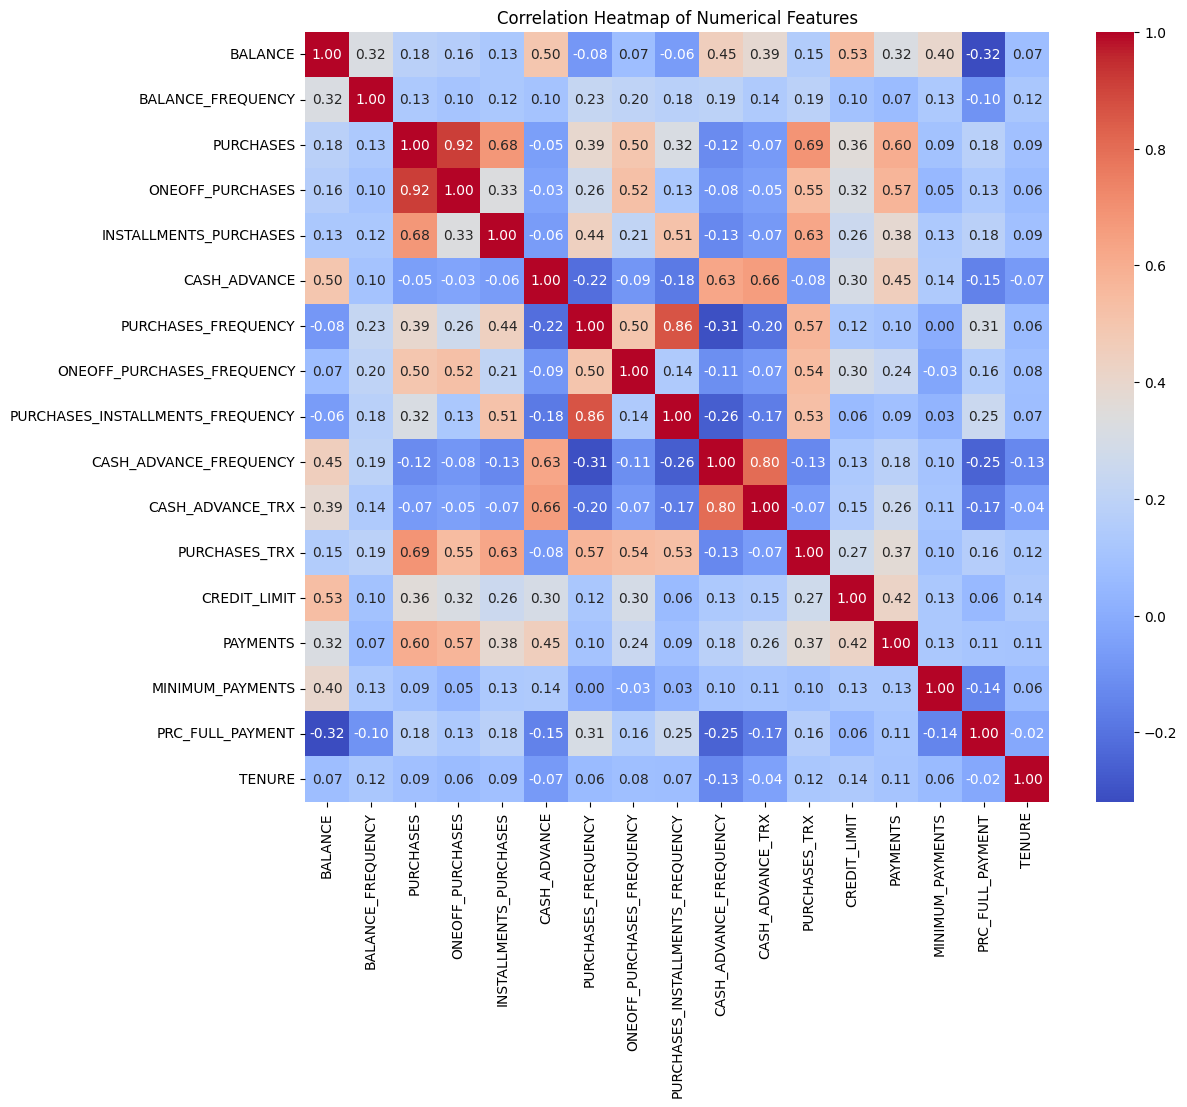

In [ ]:
plt.figure(figsize=(12,10))
corr = df.drop('CUST_ID', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:
df = df.drop(["CUST_ID", "ONEOFF_PURCHASES", "PURCHASES_INSTALLMENTS_FREQUENCY", "CASH_ADVANCE_TRX"], axis=1)

In [ ]:
df.shape

(8950, 14)

In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,411.067645,978.871112,0.490351,0.202458,0.135144,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,904.338115,2097.163877,0.401371,0.298336,0.200121,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.083333,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,89.000000,0.000000,0.500000,0.083333,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,468.637500,1113.821139,0.916667,0.300000,0.222222,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,22500.000000,47137.211760,1.000000,1.000000,1.500000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
df.dtypes

,0
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
CASH_ADVANCE_FREQUENCY,float64
PURCHASES_TRX,int64
CREDIT_LIMIT,float64


In [ ]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0
PURCHASES_TRX,0
CREDIT_LIMIT,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)

/tmp/ipykernel_723/1369236679.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)


In [ ]:
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

/tmp/ipykernel_723/3610250640.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)


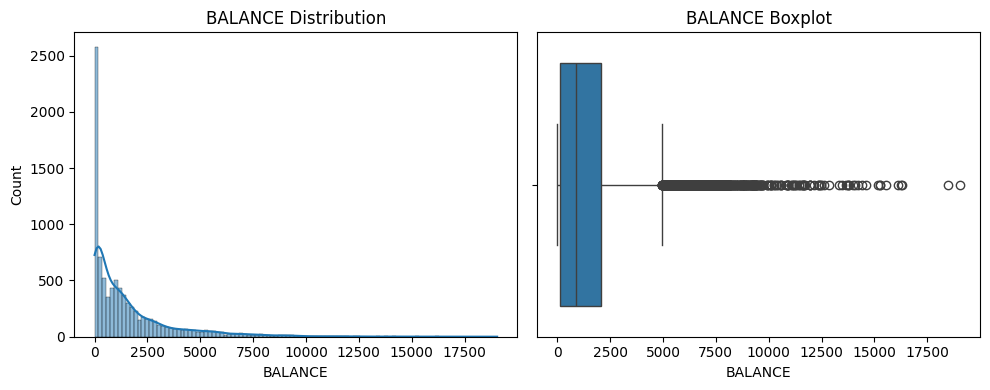

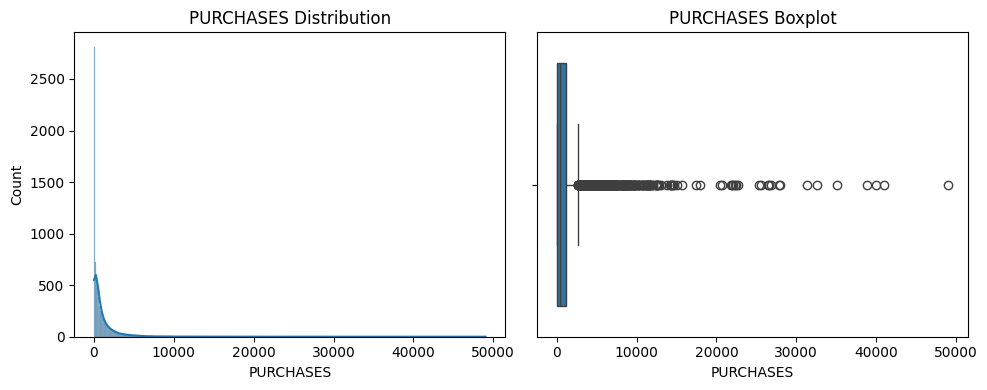

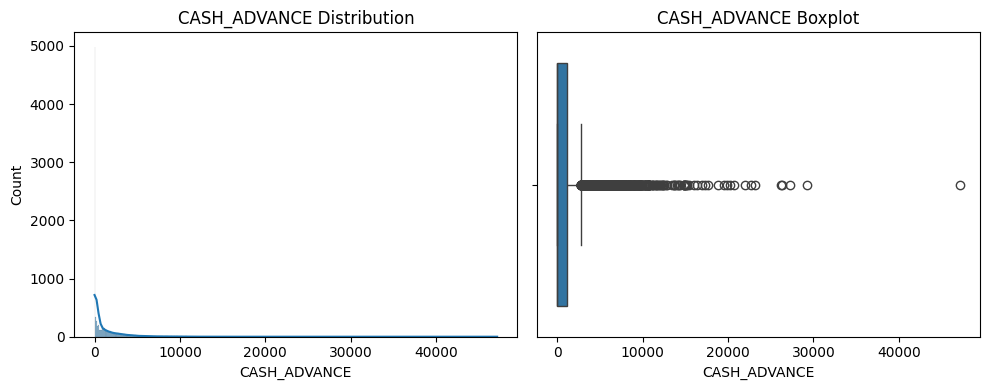

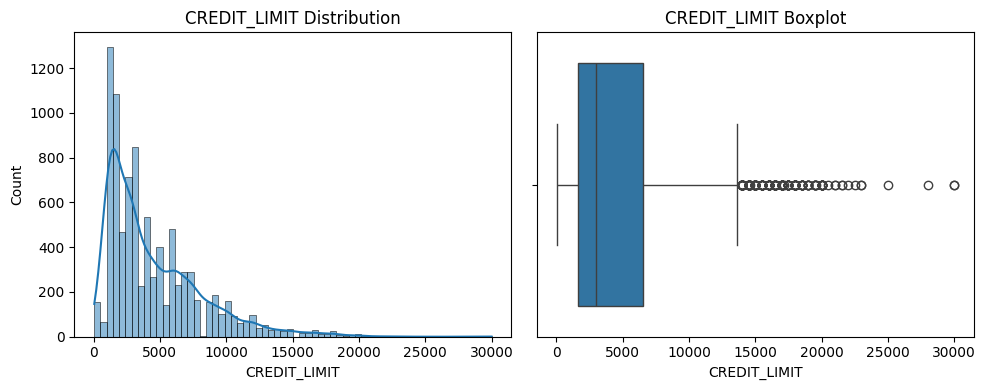

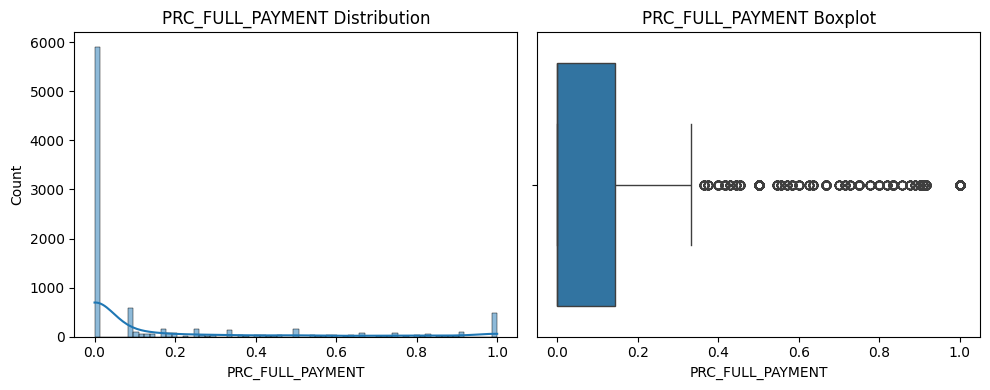

In [ ]:
features_graphed = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT']

for col in features_graphed:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()

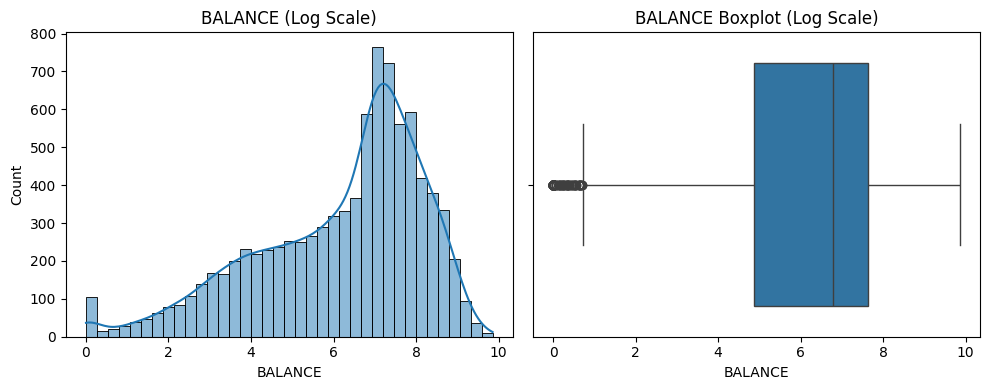

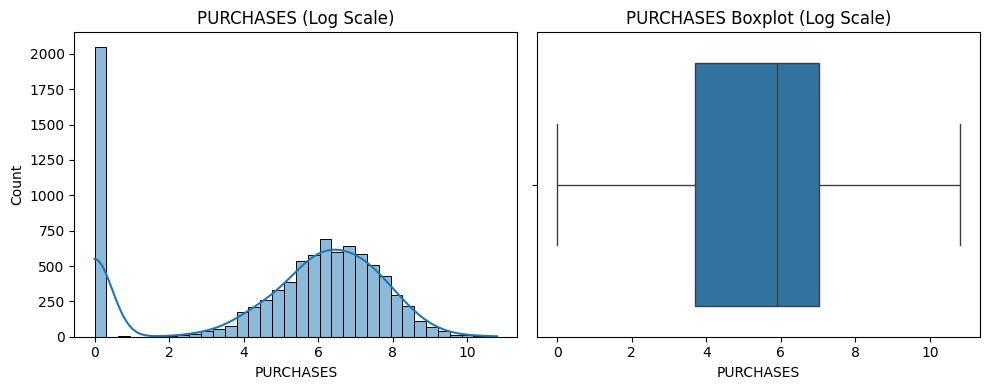

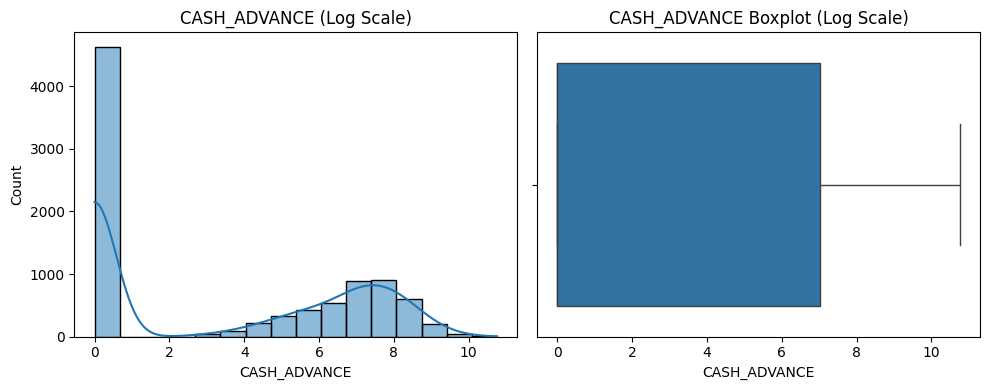

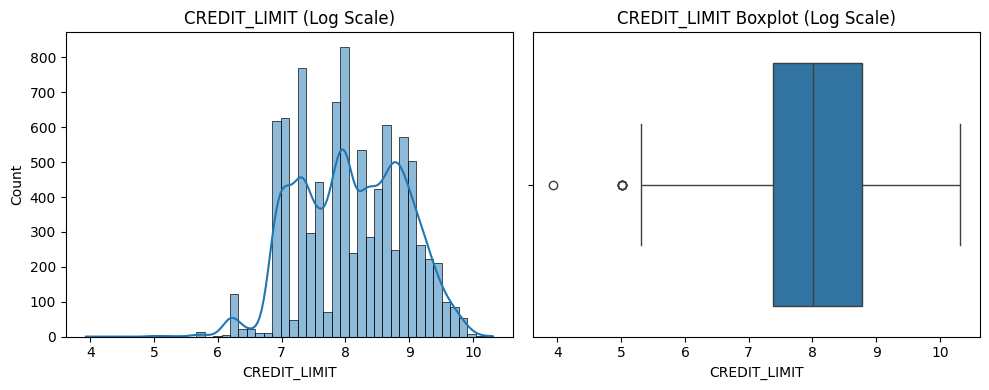

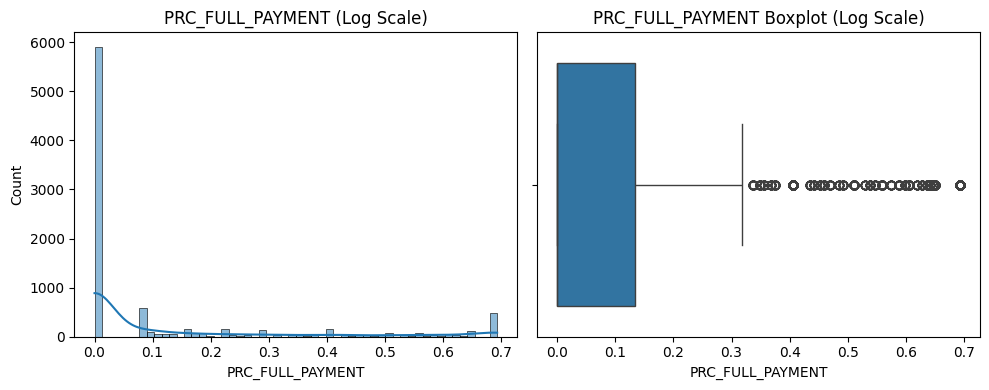

In [ ]:
import numpy as np

for col in features_graphed:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f'{col} (Log Scale)')

    plt.subplot(1,2,2)
    sns.boxplot(x=np.log1p(df[col]))
    plt.title(f'{col} Boxplot (Log Scale)')

    plt.tight_layout()
    plt.show()

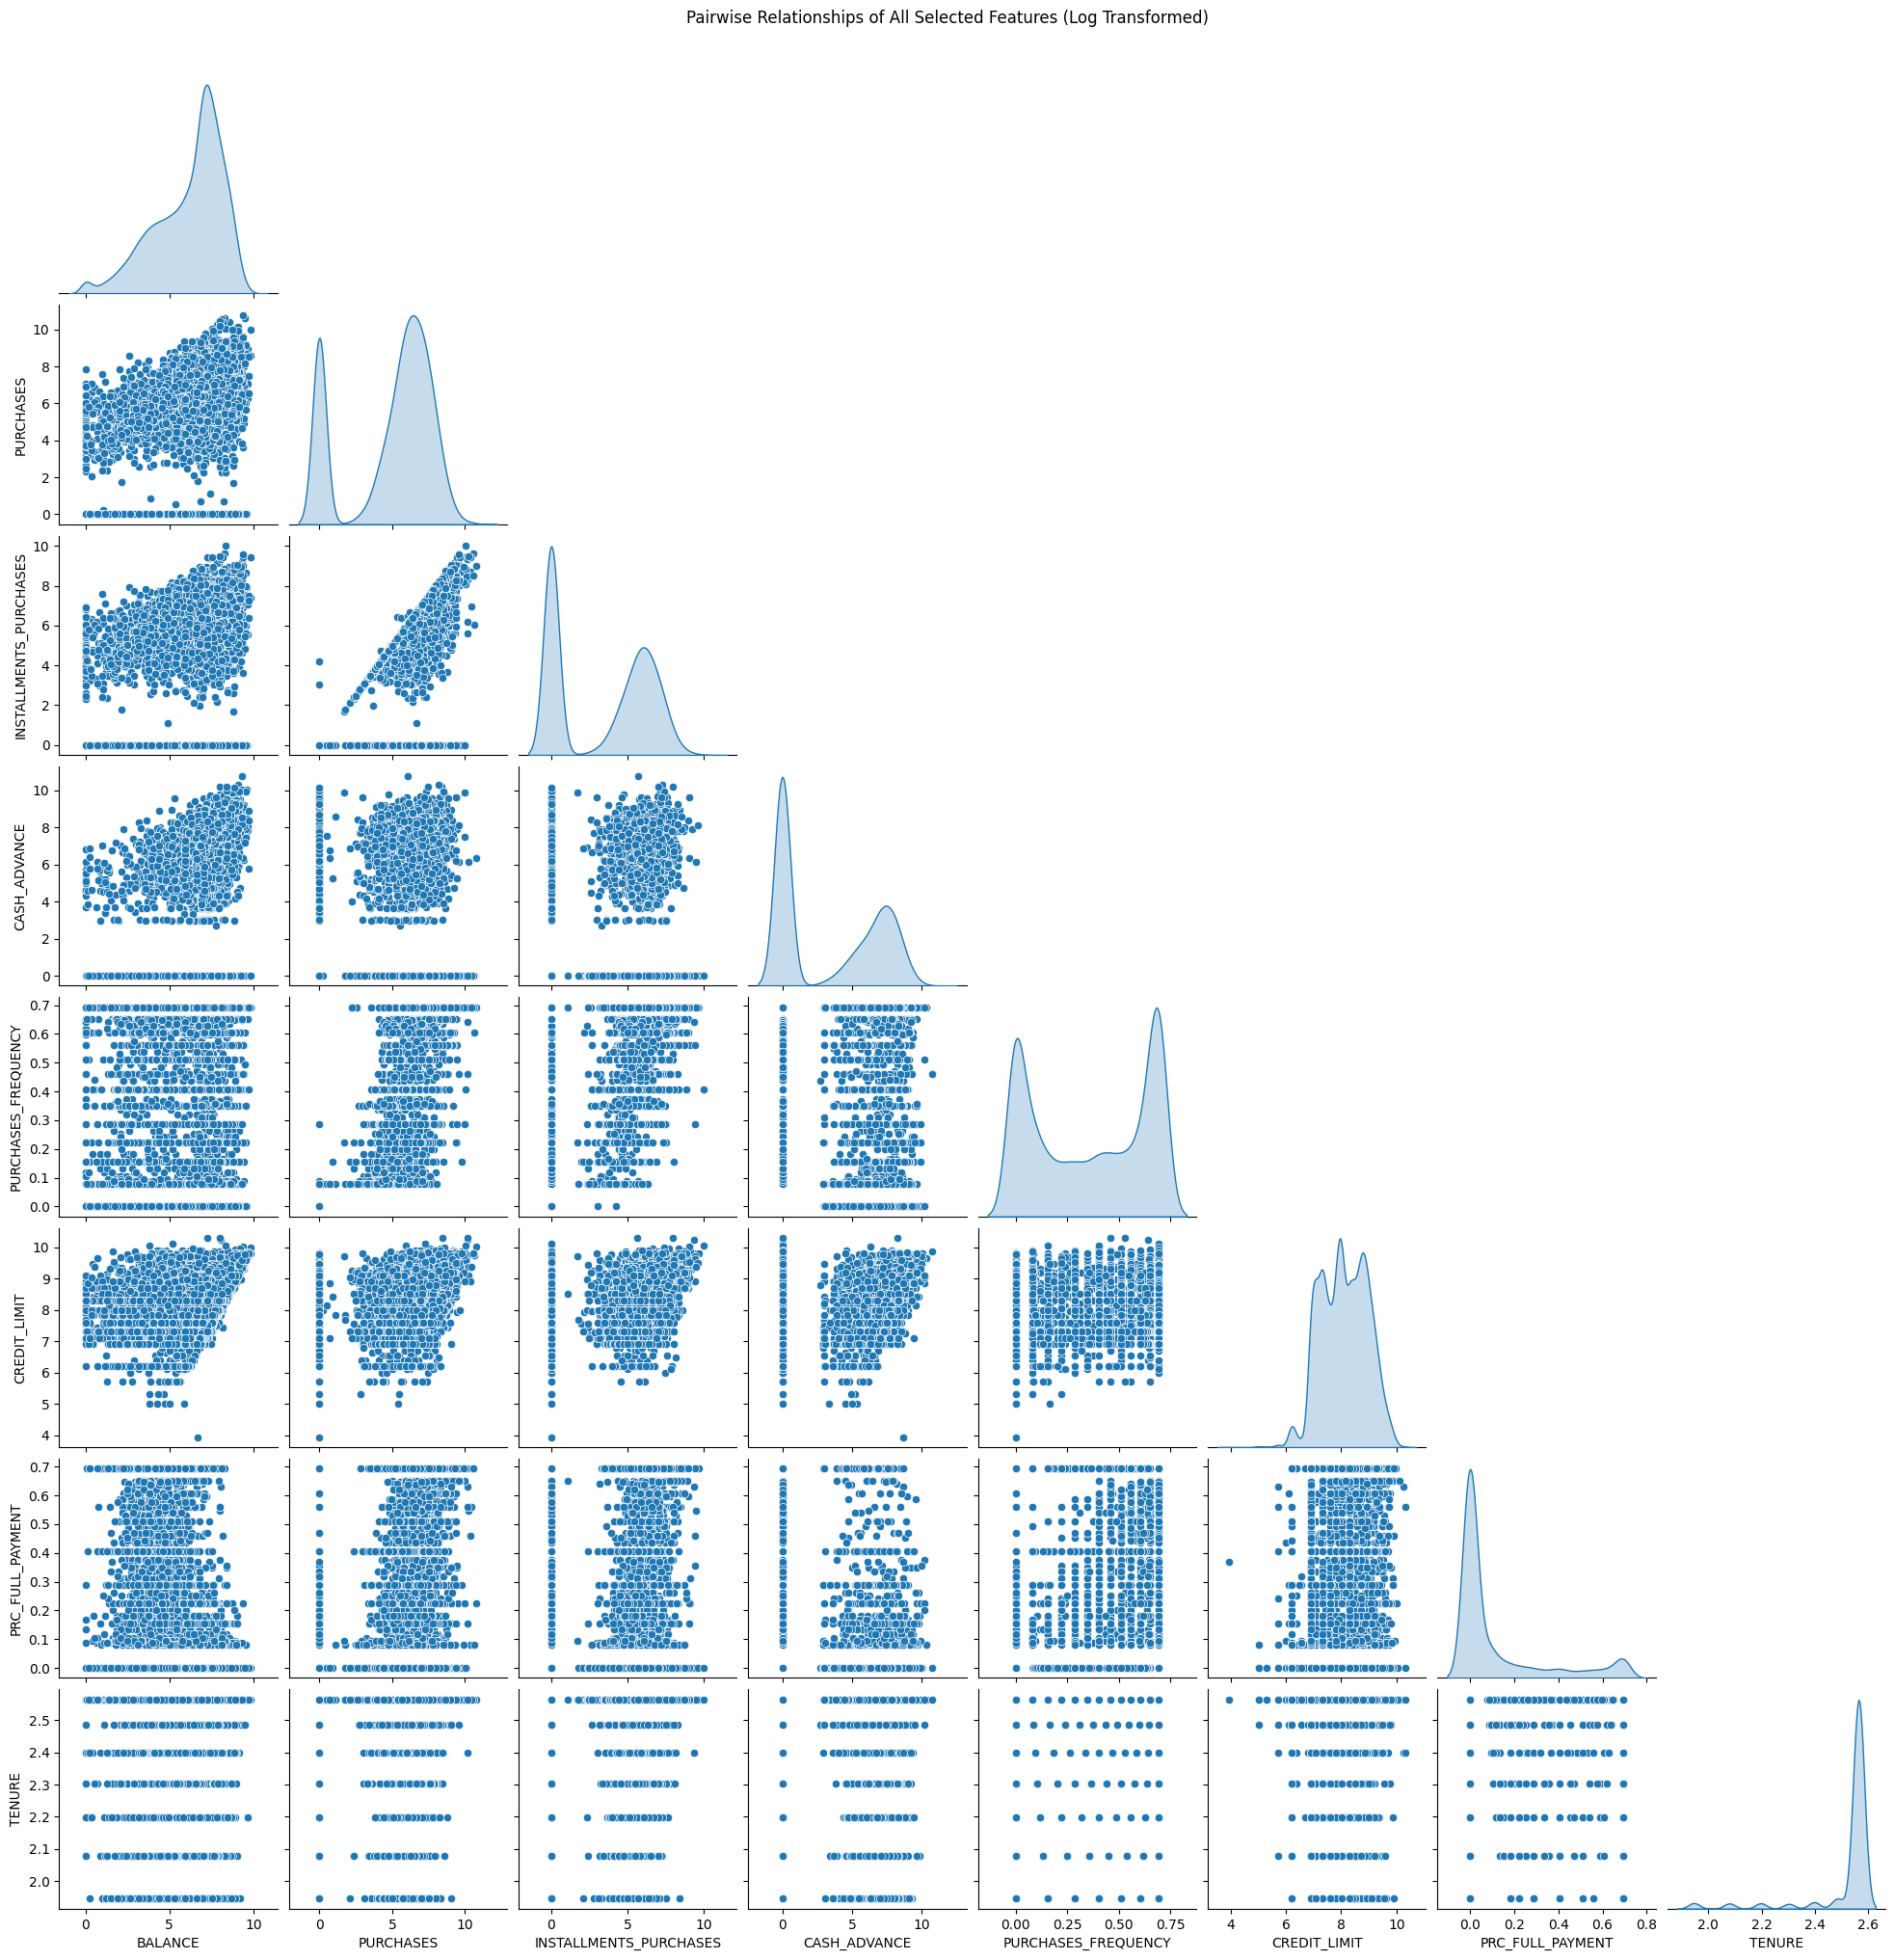

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

features_8 = [
'BALANCE',
'PURCHASES',
'INSTALLMENTS_PURCHASES',
'CASH_ADVANCE',
'PURCHASES_FREQUENCY',
'CREDIT_LIMIT',
'PRC_FULL_PAYMENT',
'TENURE'
]

# Log transform for better visualization
df_log = df[features_8].apply(np.log1p)

sns.pairplot(df_log, diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships of All Selected Features (Log Transformed)', y=1.02)
plt.show()

In [ ]:
final_features = [
    'BALANCE',
    'BALANCE_FREQUENCY',
    'PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',
    'PURCHASES_TRX',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT',
    'TENURE'
]

In [ ]:
df_final = df[final_features]

In [ ]:
df_final

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,95.40,0.000000,0.166667,0.000000,0.000000,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,6442.945483,0.000000,0.000000,0.250000,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,0.00,0.000000,1.000000,1.000000,0.000000,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,0.00,205.788017,0.083333,0.083333,0.083333,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,0.00,0.000000,0.083333,0.083333,0.000000,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,291.12,0.000000,1.000000,0.000000,0.000000,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,300.00,0.000000,1.000000,0.000000,0.000000,6,1000.0,275.861322,312.343947,0.000000,6
8947,23.398673,0.833333,144.40,144.40,0.000000,0.833333,0.000000,0.000000,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,36.558778,0.000000,0.000000,0.166667,0,500.0,52.549959,55.755628,0.250000,6


In [ ]:
outlier_summary = {}

for col in final_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

# Show results
outlier_summary_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
outlier_summary_df.sort_values(by='Outlier Count', ascending=False)

,Outlier Count
BALANCE_FREQUENCY,1493
PRC_FULL_PAYMENT,1474
TENURE,1366
CASH_ADVANCE,1030
MINIMUM_PAYMENTS,909
INSTALLMENTS_PURCHASES,867
PURCHASES,808
PAYMENTS,808
ONEOFF_PURCHASES_FREQUENCY,782
PURCHASES_TRX,766


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
df_scaled = scaler.fit_transform(df_final)

# Convert back to DataFrame (important for readability)
df_scaled = pd.DataFrame(df_scaled, columns=final_features)

df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.349079,-0.466786,-0.806490,-0.678661,-0.675349,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.454576,2.605605,-1.221758,-0.678661,0.573963,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,-0.454576,-0.466786,1.269843,2.673451,-0.675349,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,-0.454576,-0.368653,-1.014125,-0.399319,-0.258913,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.454576,-0.466786,-1.014125,-0.399319,-0.675349,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


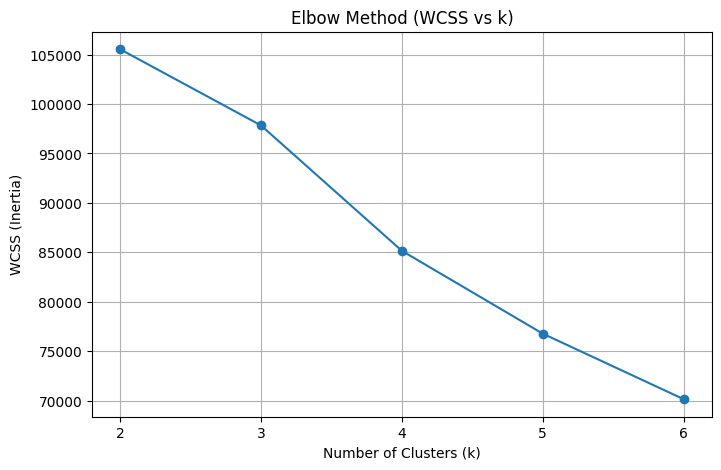

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.title('Elbow Method (WCSS vs k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)
    scores.append(score)

    print(f"k = {k}, Silhouette Score = {score}")

k = 2, Silhouette Score = 0.29267696504664603
k = 3, Silhouette Score = 0.2527068970042622
k = 4, Silhouette Score = 0.180746879706373
k = 5, Silhouette Score = 0.18974841635587048
k = 6, Silhouette Score = 0.2107901438468051


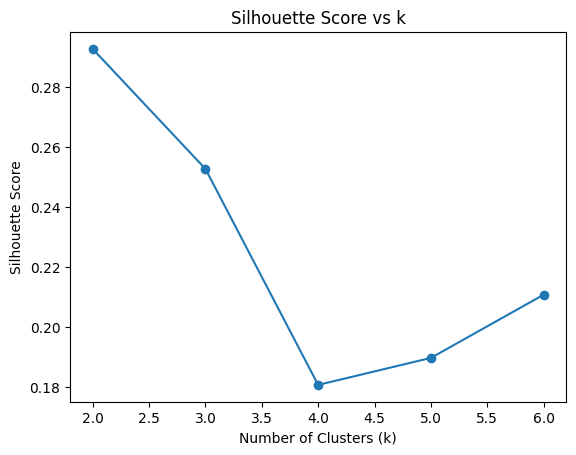

In [ ]:
import matplotlib.pyplot as plt

plt.plot(k_values, scores, marker='o')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# K-Means model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    max_iter=300,
    n_init=10
)

# Fit model and get cluster labels
kmeans_labels = kmeans.fit_predict(df_scaled)

# Add labels to a copy of your original data
df_kmeans = df.copy()
df_kmeans['KMeans_Cluster'] = kmeans_labels

# Cluster sizes
cluster_sizes = df_kmeans['KMeans_Cluster'].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_sizes)
print("\nInertia (WCSS):", kmeans.inertia_)

Cluster sizes:
KMeans_Cluster
0    3209
1    4175
2    1257
3     309
Name: count, dtype: int64

Inertia (WCSS): 83221.7487120903


In [ ]:
cluster_summary = cluster_sizes.reset_index()
cluster_summary.columns = ['Cluster', 'Number of Samples']
cluster_summary

,Cluster,Number of Samples
0,0,3209
1,1,4175
2,2,1257
3,3,309


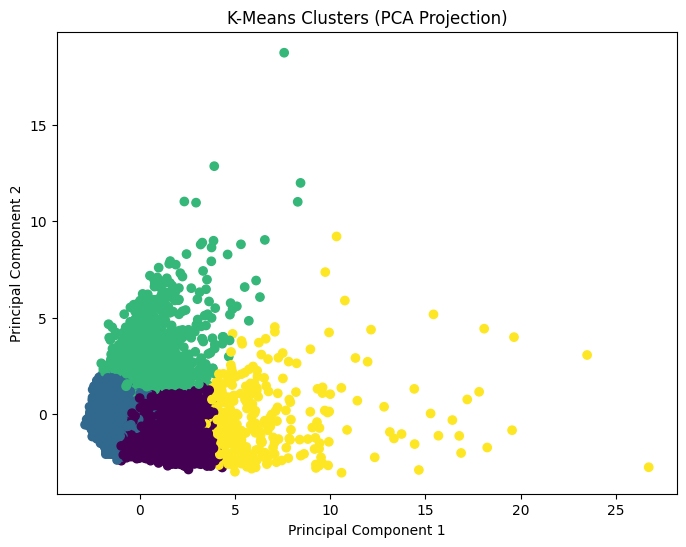

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels)
plt.title('K-Means Clusters (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


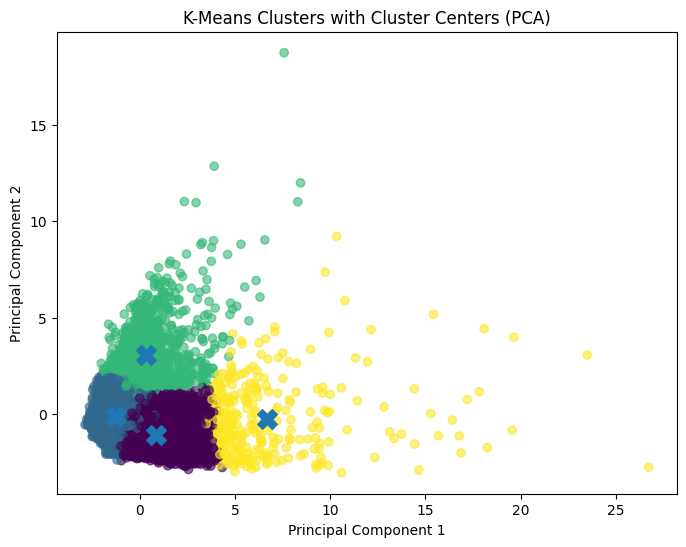

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA transform
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Transform cluster centers into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

# Plot data points
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels, alpha=0.6)

# Plot cluster centers
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=200)

plt.title('K-Means Clusters with Cluster Centers (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [ ]:
cluster_means = df_kmeans.groupby('KMeans_Cluster')[final_features].mean()
cluster_means

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,,,
0,940.864775,0.958777,1458.549103,649.206195,200.044149,0.879402,0.360871,0.041582,23.938299,4555.104819,1522.163207,561.605358,0.286576,11.717357
1,903.788233,0.779668,244.883107,86.708213,569.375367,0.215223,0.065139,0.117564,3.287665,3019.351430,853.578501,513.788252,0.079453,11.343713
2,4761.818268,0.966760,538.681337,195.616245,4371.703468,0.294864,0.128994,0.444868,7.627685,7860.783250,3604.842988,2301.230843,0.032034,11.474940
3,3960.819449,0.985525,8409.999288,3196.946052,797.997944,0.962567,0.711528,0.084383,102.009709,10096.116505,8194.297307,2336.604668,0.272290,11.957929


In [ ]:
cluster_means_scaled = df_scaled.copy()
cluster_means_scaled['Cluster'] = kmeans_labels

cluster_profile = cluster_means_scaled.groupby('Cluster').mean()
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,
0,-0.299609,0.344067,0.213125,0.263344,-0.371392,0.969362,0.531020,-0.467554,0.371273,0.016717,-0.072880,-0.121450,0.454255,0.149477
1,-0.317422,-0.412016,-0.354934,-0.358691,-0.195273,-0.685507,-0.460309,-0.087851,-0.459529,-0.405374,-0.303833,-0.141949,-0.253900,-0.129725
2,1.536139,0.377766,-0.217421,-0.238255,1.617910,-0.487074,-0.246259,1.547767,-0.284924,0.925259,0.646550,0.624319,-0.416026,-0.031667
3,1.151305,0.456980,3.466764,3.080744,-0.086251,1.176576,1.706460,-0.253668,3.512189,1.539624,2.231907,0.639483,0.405410,0.329242


In [ ]:
# Map K-Means cluster numbers to A/B/C/D labels
cluster_map = {
    1: 'A',  # Low activity users
    3: 'B',  # High spenders
    2: 'C',  # High balance / cash-advance users
    0: 'D'   # Moderate / frequent-paying users
}

df_kmeans['Cluster_Label'] = df_kmeans['KMeans_Cluster'].map(cluster_map)

In [ ]:
cluster_profile = cluster_profile.rename(index=cluster_map)
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,
D,-0.299609,0.344067,0.213125,0.263344,-0.371392,0.969362,0.531020,-0.467554,0.371273,0.016717,-0.072880,-0.121450,0.454255,0.149477
A,-0.317422,-0.412016,-0.354934,-0.358691,-0.195273,-0.685507,-0.460309,-0.087851,-0.459529,-0.405374,-0.303833,-0.141949,-0.253900,-0.129725
C,1.536139,0.377766,-0.217421,-0.238255,1.617910,-0.487074,-0.246259,1.547767,-0.284924,0.925259,0.646550,0.624319,-0.416026,-0.031667
B,1.151305,0.456980,3.466764,3.080744,-0.086251,1.176576,1.706460,-0.253668,3.512189,1.539624,2.231907,0.639483,0.405410,0.329242


In [ ]:
# Map K-Means cluster numbers to A/B/C/D
cluster_map = {
    0: 'D',
    1: 'A',
    2: 'C',
    3: 'B'
}

# Add letter labels
df_kmeans['Cluster_Label'] = df_kmeans['KMeans_Cluster'].map(cluster_map)

# Count size of each lettered cluster
cluster_size_by_letter = (
    df_kmeans['Cluster_Label']
    .value_counts()
    .reindex(['A', 'B', 'C', 'D'])
    .reset_index()
)

cluster_size_by_letter.columns = ['Cluster', 'Count']

cluster_size_by_letter

,Cluster,Count
0,A,4175
1,B,309
2,C,1257
3,D,3209


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


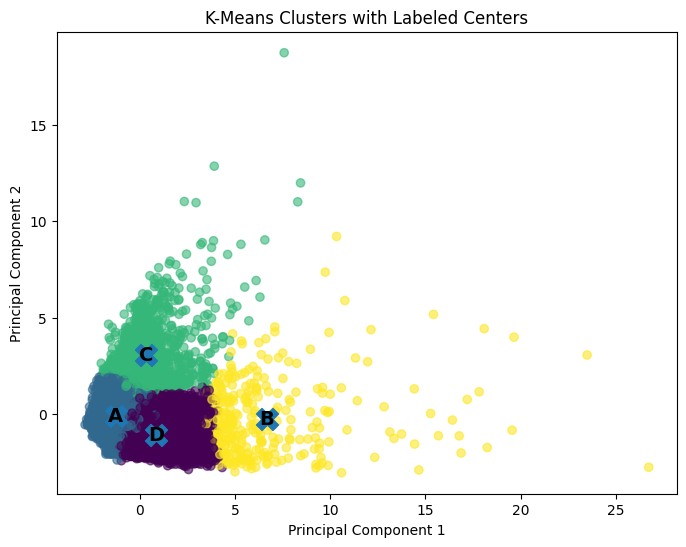

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA transform
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Transform cluster centers into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

# Your cluster mapping
cluster_map = {
    1: 'A',  # Low activity
    3: 'B',  # High spenders
    2: 'C',  # High balance / cash advance
    0: 'D'   # Moderate users
}

# Plot points
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels, alpha=0.6)

# Plot centers
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=250)

# Label each center with A/B/C/D
for i, (x, y) in enumerate(centers_pca):
    label = cluster_map[i]
    plt.text(x, y, label, fontsize=14, fontweight='bold', ha='center', va='center')

plt.title('K-Means Clusters with Labeled Centers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [ ]:
# K-Means cluster sizes
cluster_counts = df_kmeans['KMeans_Cluster'].value_counts().sort_index()

# Percentages
cluster_percent = (cluster_counts / len(df_kmeans)) * 100

cluster_summary = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Count': cluster_counts.values,
    'Percentage (%)': cluster_percent.values
})

cluster_summary

,Cluster,Count,Percentage (%)
0,0,3209,35.854749
1,1,4175,46.648045
2,2,1257,14.044693
3,3,309,3.452514


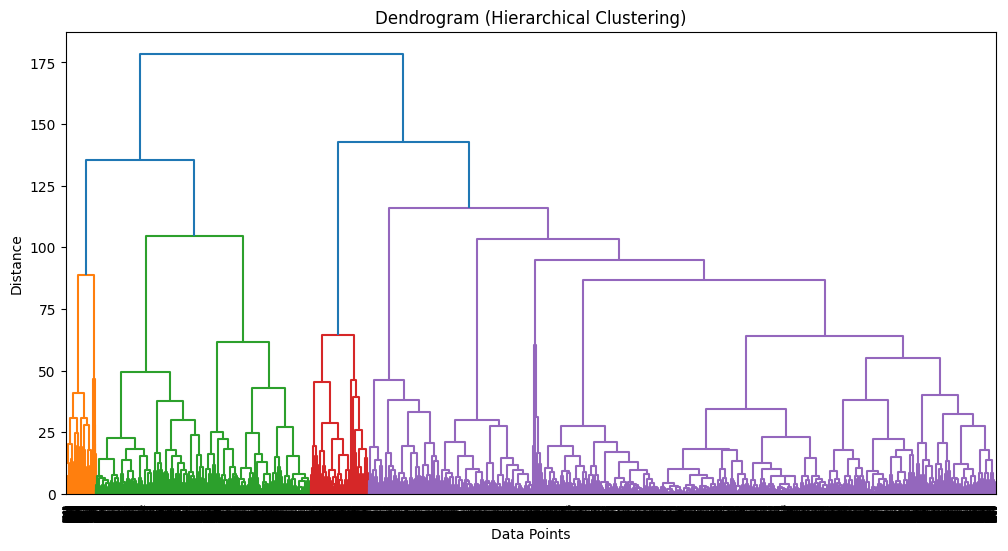

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Create linkage matrix (Ward is best for your case)
linked = linkage(df_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked)

plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Data Points')
plt.ylabel('Distance')

plt.show()

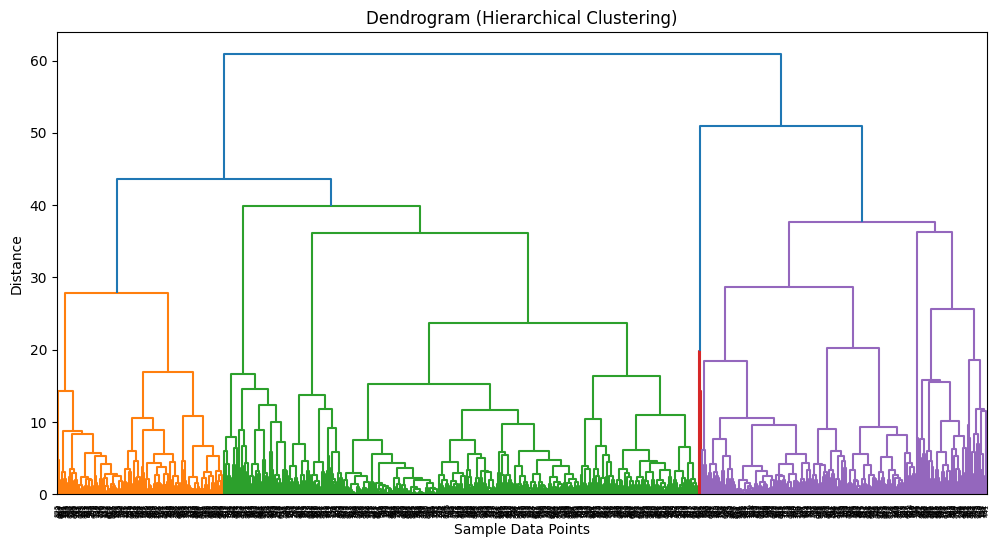

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Linkage (Ward method)
linked = linkage(df_scaled, method='ward')

# Step 2: Dendrogram (use sample for readability)
sample = df_scaled.sample(1000, random_state=42)

plt.figure(figsize=(12,6))
dendrogram(linkage(sample, method='ward'))

plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Sample Data Points')
plt.ylabel('Distance')
plt.show()

In [ ]:
hierarchical_labels = fcluster(linked, t=4, criterion='maxclust')

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

# Step 1: Create linkage
linked = linkage(df_scaled, method='ward')

# Step 2: Get cluster labels (k = 4)
hierarchical_labels = fcluster(linked, t=4, criterion='maxclust')

# Step 3: Compute silhouette score
hierarchical_silhouette = silhouette_score(df_scaled, hierarchical_labels)

print("Hierarchical Silhouette Score:", hierarchical_silhouette)

Hierarchical Silhouette Score: 0.18729146609288022


In [ ]:
scores_hier = []
k_values = range(2, 7)

for k in k_values:
    labels = fcluster(linked, t=k, criterion='maxclust')
    score = silhouette_score(df_scaled, labels)
    scores_hier.append(score)

    print(f"k = {k}, Hierarchical Silhouette Score = {score}")

k = 2, Hierarchical Silhouette Score = 0.21506825560547302
k = 3, Hierarchical Silhouette Score = 0.21962094190868275
k = 4, Hierarchical Silhouette Score = 0.18729146609288022
k = 5, Hierarchical Silhouette Score = 0.20164150979137097
k = 6, Hierarchical Silhouette Score = 0.20640768815999322


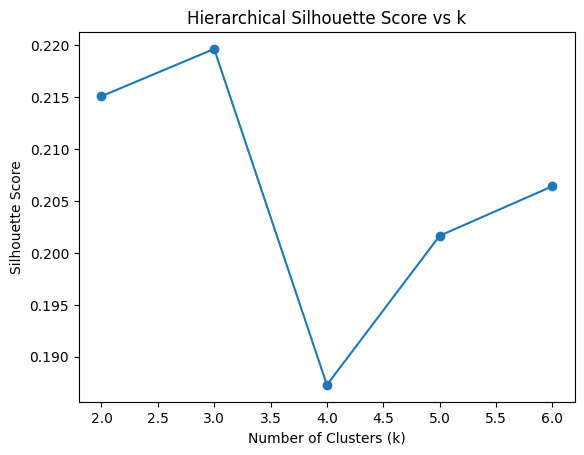

In [ ]:
import matplotlib.pyplot as plt

plt.plot(k_values, scores_hier, marker='o')
plt.title('Hierarchical Silhouette Score vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

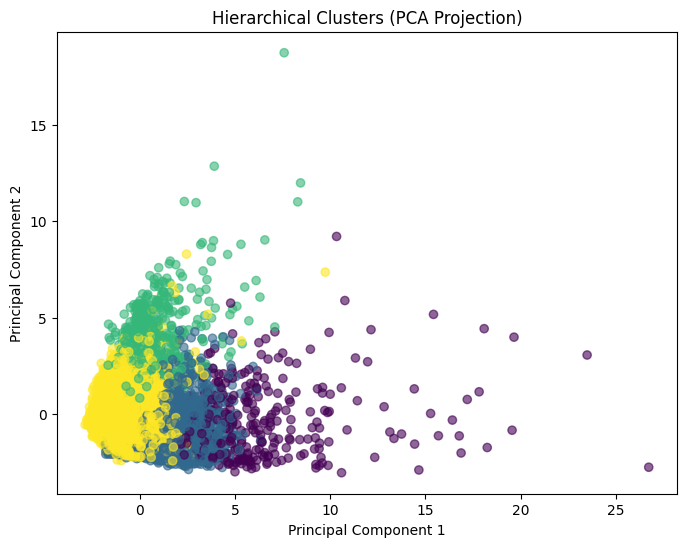

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA transform (same as K-Means)
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Plot hierarchical clusters
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=hierarchical_labels, alpha=0.6)

plt.title('Hierarchical Clusters (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [ ]:
df_hierarchical = df.copy()
df_hierarchical['Cluster'] = hierarchical_labels

hier_means = df_hierarchical.groupby('Cluster')[final_features].mean()
hier_means

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,
1,3596.301935,0.984145,8237.235427,3533.909249,872.797436,0.956221,0.606955,0.089409,98.235495,9582.252560,8119.205113,2003.518226,0.285711,11.962457
2,1143.997344,0.906450,1825.600242,614.918908,368.508835,0.833965,0.500741,0.057117,27.254712,5508.377418,1991.834564,506.977508,0.421367,11.944901
3,6051.378080,0.963085,475.394506,187.363411,5898.826619,0.259145,0.108073,0.508539,6.490126,9367.324955,4729.653803,2042.365257,0.033905,11.256732
4,1195.620153,0.854143,418.373676,210.079816,739.027624,0.371190,0.089194,0.129649,7.107445,3449.145291,1057.401342,793.956360,0.066546,11.373072


In [ ]:
# Count hierarchical cluster sizes
cluster_counts = (
    df_hierarchical['Cluster']
    .value_counts()
    .sort_index()
)

# Percentages
cluster_percent = (cluster_counts / len(df_hierarchical)) * 100

# Combine into one table
hier_cluster_summary = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Count': cluster_counts.values,
    'Percentage (%)': cluster_percent.values
})

hier_cluster_summary

,Cluster,Count,Percentage (%)
0,1,293,3.273743
1,2,2069,23.117318
2,3,557,6.223464
3,4,6031,67.385475


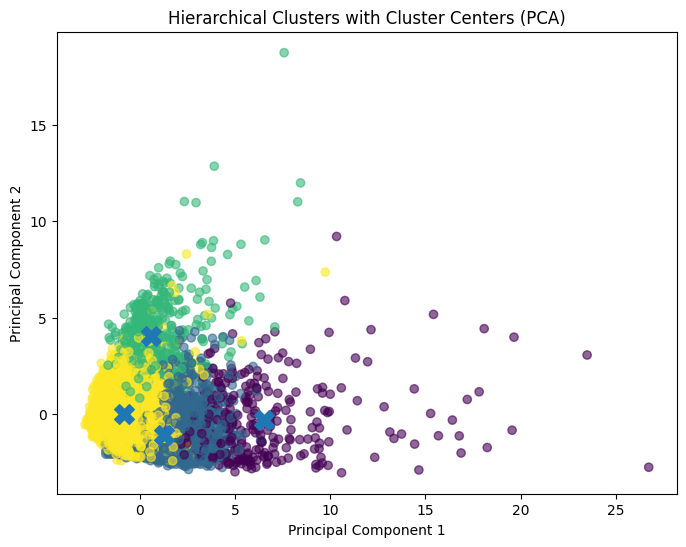

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# PCA transform
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Put PCA coordinates into a DataFrame
df_pca_df = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca_df['Hierarchical_Cluster'] = hierarchical_labels

# Compute "cluster centers" as mean PCA position of each hierarchical cluster
hier_centers = df_pca_df.groupby('Hierarchical_Cluster')[['PC1', 'PC2']].mean()

# Plot data points
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=hierarchical_labels, alpha=0.6)

# Plot hierarchical cluster centers
plt.scatter(hier_centers['PC1'], hier_centers['PC2'], marker='X', s=200)

plt.title('Hierarchical Clusters with Cluster Centers (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [ ]:
import pandas as pd

# Step 1: Use your scaled data (already standardized)
df_hier_scaled = df_scaled.copy()

# Step 2: Add hierarchical cluster labels
df_hier_scaled['Cluster'] = hierarchical_labels

# Step 3: Compute mean of each feature per cluster
hier_cluster_profile = df_hier_scaled.groupby('Cluster').mean()

hier_cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,
1,0.976176,0.451155,3.385901,3.453372,-0.050582,1.160763,1.355921,-0.228548,3.360347,1.398392,2.205968,0.496691,0.451297,0.332626
2,-0.202015,0.123177,0.384924,0.225427,-0.291058,0.856151,0.999879,-0.389920,0.504697,0.278717,0.089361,-0.144869,0.915104,0.319507
3,2.155698,0.362253,-0.247043,-0.247382,2.346135,-0.576072,-0.316389,1.865948,-0.330690,1.339321,1.035099,0.513344,-0.409630,-0.194721
4,-0.177213,-0.097632,-0.273731,-0.222261,-0.114372,-0.296901,-0.379673,-0.027462,-0.305854,-0.287248,-0.233425,-0.021842,-0.298029,-0.107787


In [ ]:
hier_map = {
    4: 'A',  # Low activity users
    1: 'B',  # High spenders
    3: 'C',  # High balance / cash advance users
    2: 'D'   # Moderate / frequent-paying users
}

df_hierarchical['Cluster_Label'] = df_hierarchical['Cluster'].map(hier_map)

In [ ]:
df_hierarchical.groupby('Cluster_Label')[final_features].mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster_Label,,,,,,,,,,,,,,
A,1195.620153,0.854143,418.373676,210.079816,739.027624,0.371190,0.089194,0.129649,7.107445,3449.145291,1057.401342,793.956360,0.066546,11.373072
B,3596.301935,0.984145,8237.235427,3533.909249,872.797436,0.956221,0.606955,0.089409,98.235495,9582.252560,8119.205113,2003.518226,0.285711,11.962457
C,6051.378080,0.963085,475.394506,187.363411,5898.826619,0.259145,0.108073,0.508539,6.490126,9367.324955,4729.653803,2042.365257,0.033905,11.256732
D,1143.997344,0.906450,1825.600242,614.918908,368.508835,0.833965,0.500741,0.057117,27.254712,5508.377418,1991.834564,506.977508,0.421367,11.944901


In [ ]:
df_hier_scaled['Cluster_Label'] = df_hier_scaled['Cluster'].map(hier_map)

# Step 4: Group by labeled clusters
hier_cluster_profile = df_hier_scaled.groupby('Cluster_Label').mean()

hier_cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
Cluster_Label,,,,,,,,,,,,,,,
A,-0.177213,-0.097632,-0.273731,-0.222261,-0.114372,-0.296901,-0.379673,-0.027462,-0.305854,-0.287248,-0.233425,-0.021842,-0.298029,-0.107787,4.0
B,0.976176,0.451155,3.385901,3.453372,-0.050582,1.160763,1.355921,-0.228548,3.360347,1.398392,2.205968,0.496691,0.451297,0.332626,1.0
C,2.155698,0.362253,-0.247043,-0.247382,2.346135,-0.576072,-0.316389,1.865948,-0.330690,1.339321,1.035099,0.513344,-0.409630,-0.194721,3.0
D,-0.202015,0.123177,0.384924,0.225427,-0.291058,0.856151,0.999879,-0.389920,0.504697,0.278717,0.089361,-0.144869,0.915104,0.319507,2.0


In [ ]:
# Counts
cluster_counts = df_hierarchical['Cluster_Label'].value_counts()

# Percentages
cluster_percent = (cluster_counts / len(df_hierarchical)) * 100

# Combine into one table
cluster_summary = pd.DataFrame({
    'Count': cluster_counts,
    'Percentage (%)': cluster_percent
})

cluster_summary

,Count,Percentage (%)
Cluster_Label,,
A,6031,67.385475
D,2069,23.117318
C,557,6.223464
B,293,3.273743


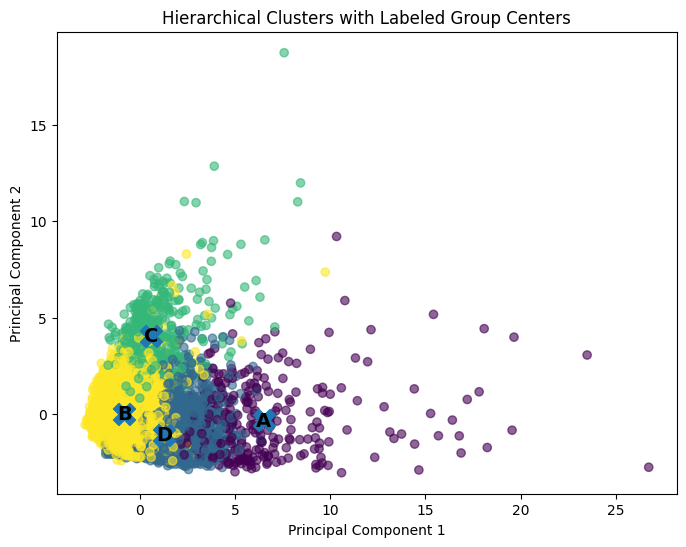

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# PCA transform
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Put PCA coords into a dataframe
df_hier_plot = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_hier_plot['Hierarchical_Cluster'] = hierarchical_labels

# Map hierarchical cluster numbers to A/B/C/D
# IMPORTANT: adjust these numbers only if your hierarchical cluster means differ
hier_map = {
    1: 'A',  # Low activity users
    4: 'B',  # High spenders
    3: 'C',  # High balance / cash advance users
    2: 'D'   # Moderate / frequent-paying users
}

df_hier_plot['Cluster_Label'] = df_hier_plot['Hierarchical_Cluster'].map(hier_map)

# Compute "center" of each hierarchical cluster in PCA space
hier_centers = df_hier_plot.groupby('Hierarchical_Cluster')[['PC1', 'PC2']].mean()

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df_hier_plot['PC1'], df_hier_plot['PC2'], c=df_hier_plot['Hierarchical_Cluster'], alpha=0.6)

# Plot cluster center markers
plt.scatter(hier_centers['PC1'], hier_centers['PC2'], marker='X', s=250)

# Label each center with A/B/C/D
for cluster_num, row in hier_centers.iterrows():
    label = hier_map[cluster_num]
    plt.text(row['PC1'], row['PC2'], label, fontsize=14, fontweight='bold',
             ha='center', va='center')

plt.title('Hierarchical Clusters with Labeled Group Centers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [ ]:
import pandas as pd

# The silhouette score for KMeans with k=4 is the 3rd element (index 2) in the scores list
# as k_values started from 2.
kmeans_silhouette = scores[2]

comparison_table = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical'],
    'Clusters (k)': [4, 4],
    'ARI Score': ['N/A', 'N/A'],
    'Inertia (WCSS)': [kmeans.inertia_, 'N/A'],
    'Silhouette Score': [kmeans_silhouette, hierarchical_silhouette]
})

comparison_table

,Algorithm,Clusters (k),ARI Score,Inertia (WCSS),Silhouette Score
0,K-Means,4,N/A,83221.748712,0.180747
1,Hierarchical,4,N/A,N/A,0.187291


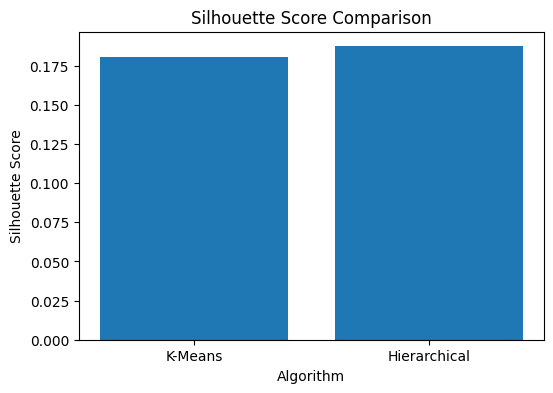

In [ ]:
import matplotlib.pyplot as plt

algorithms = ['K-Means', 'Hierarchical']
scores = [kmeans_silhouette, hierarchical_silhouette]

plt.figure(figsize=(6,4))
plt.bar(algorithms, scores)

plt.title('Silhouette Score Comparison')
plt.ylabel('Silhouette Score')
plt.xlabel('Algorithm')

plt.show()

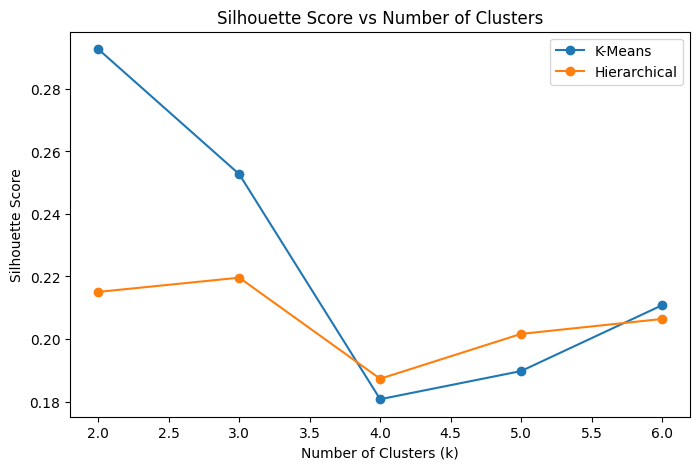

In [ ]:
plt.figure(figsize=(8,5))

# Reconstructing K-Means silhouette scores from previous calculations (cell BoFIopWrver-)
kmeans_scores_over_k = [
    0.29267696504664603, # k=2
    0.2527068970042622,  # k=3
    0.180746879706373,   # k=4
    0.18974841635587048, # k=5
    0.2107901438468051   # k=6
]

plt.plot(range(2,7), kmeans_scores_over_k, marker='o', label='K-Means')
plt.plot(range(2,7), scores_hier, marker='o', label='Hierarchical')

plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()

plt.show()

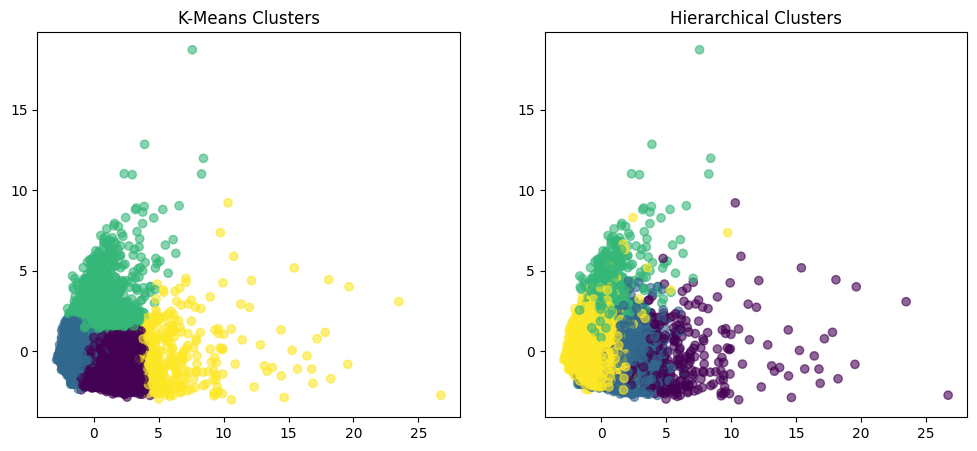

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# K-Means
axes[0].scatter(df_pca[:,0], df_pca[:,1], c=kmeans_labels, alpha=0.6)
axes[0].set_title('K-Means Clusters')

# Hierarchical
axes[1].scatter(df_pca[:,0], df_pca[:,1], c=hierarchical_labels, alpha=0.6)
axes[1].set_title('Hierarchical Clusters')

plt.show()